In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

#### Compute percentile/quantile, mean, standard deviation, anomaly, Z-score
#### X is 1-D array

In [3]:
X = np.array([3, 8, 8, 6, 7, 9, 5, 10, 11, 20, 19, 15, 11, 16])
q25 = np.percentile(X,25)
q50 = np.percentile(X,50)
q75 = np.percentile(X,75)
print(q25,q50,q75)

q25 = np.quantile(X,0.25)
q50 = np.quantile(X,0.5)
q75 = np.quantile(X,0.75)
print(q25,q50,q75)

7.25 9.5 14.0
7.25 9.5 14.0


In [8]:
Y = np.arange(0,12).reshape(3,4)
print(Y)
y_q25 = np.percentile(Y,25,axis=1)
print(y_q25)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[0.75 4.75 8.75]


#### Test what the function will produce given different methods

In [4]:
q25_1 = np.quantile(X,0.25,method='nearest')
q25_2 = np.quantile(X,0.25,method='midpoint')
q25_3 = np.quantile(X,0.25,method='linear')
print(q25_1,q25_2,q25_3)

7 7.5 7.25


#### Mean and standard deviation

In [10]:
X = np.array([3, 8, 8, 6, 7, 9, 5, 10, 11, 20, 19, 15, 11, 16])
xmean = np.mean(X)
xsig = np.std(X)
xstd = np.std(X,ddof=1)
print(xmean,xsig,xstd)

10.571428571428571 4.981598792617913 5.169649381270912


#### X is 2-D array

In [12]:
X = np.arange(0, 12).reshape(3, 4)
print(X)
xmean_1 = np.mean(X,axis=0)
xmean_2 = np.mean(X,axis=1)
xmean = np.mean(X)
print(xmean_1,xmean_2,xmean)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[4. 5. 6. 7.] [1.5 5.5 9.5] 5.5


#### Anomaly and Z-score

In [20]:
X = np.array([3, 8, 8, 6, 7, 9, 5, 10, 11, 20, 19, 15, 11, 16])
xmean = np.mean(X)
X_anom = X-xmean
print('mean:',xmean)
print('anomaly:',X_anom)

xstd = np.std(X,ddof=1)
X_z = X_anom/xstd
print('STD:',xstd)
print('Z-scor:',X_z)

mean: 10.571428571428571
anomaly: [-7.57142857 -2.57142857 -2.57142857 -4.57142857 -3.57142857 -1.57142857
 -5.57142857 -0.57142857  0.42857143  9.42857143  8.42857143  4.42857143
  0.42857143  5.42857143]
STD: 5.169649381270912
Z-scor: [-1.46459228 -0.4974087  -0.4974087  -0.88428213 -0.69084541 -0.30397198
 -1.07771885 -0.11053527  0.08290145  1.8238319   1.63039518  0.85664831
  0.08290145  1.05008503]


In [17]:
Y = np.arange(100).reshape(50,2)
print(Y)
# mean of Y along first dimension
# STD of Y along first dimension
# anomaly and standardized anomaly of Y along first dimension
ymean = np.mean(Y,axis=0)
ystd = np.std(Y,axis=0)
print(ymean, ystd)

yanom = Y-ymean
print(yanom.shape)
y_z = yanom/ystd
print(y_z.shape)

[[ 0  1]
 [ 2  3]
 [ 4  5]
 [ 6  7]
 [ 8  9]
 [10 11]
 [12 13]
 [14 15]
 [16 17]
 [18 19]
 [20 21]
 [22 23]
 [24 25]
 [26 27]
 [28 29]
 [30 31]
 [32 33]
 [34 35]
 [36 37]
 [38 39]
 [40 41]
 [42 43]
 [44 45]
 [46 47]
 [48 49]
 [50 51]
 [52 53]
 [54 55]
 [56 57]
 [58 59]
 [60 61]
 [62 63]
 [64 65]
 [66 67]
 [68 69]
 [70 71]
 [72 73]
 [74 75]
 [76 77]
 [78 79]
 [80 81]
 [82 83]
 [84 85]
 [86 87]
 [88 89]
 [90 91]
 [92 93]
 [94 95]
 [96 97]
 [98 99]]
[49. 50.] [28.86173938 28.86173938]
(50, 2)
(50, 2)


### Compute time mean, climatology, anomaly, and standardized anomaly for weather and climate studies

In [2]:
filename = '/nfs/spare11/env315/data/era5_an_t2m_reg025_6h_202512.nc'
data = xr.open_dataset(filename).compute()
data

0
1
2
3
5


/knight/mamba_aug23/envs/aug23_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gribberish' loading failed:
No module named 'gribberish'
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


<xarray.Dataset>
Dimensions:     (valid_time: 124, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 0
  * valid_time  (valid_time) datetime64[ns] 2025-12-01 ... 2025-12-31T18:00:00
  * latitude    (latitude) float64 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) object '0005' '0005' '0005' ... '0005' '0005'
Data variables:
    t2m         (valid_time, latitude, longitude) float32 253.8 253.8 ... 245.3
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-01-06T09:47 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
# convert xarray.DataSet to xarray.DataArray by selecting t2m
data = data.t2m
data

<xarray.DataArray 't2m' (valid_time: 124, latitude: 721, longitude: 1440)>
array([[[253.83292, 253.83292, 253.83292, ..., 253.83292, 253.83292,
         253.83292],
        [255.38956, 255.39151, 255.39346, ..., 255.3837 , 255.38565,
         255.3876 ],
        [256.21964, 256.22354, 256.2255 , ..., 256.21182, 256.21378,
         256.21768],
        ...,
        [245.29776, 245.29776, 245.29776, ..., 245.2958 , 245.2958 ,
         245.29776],
        [245.36417, 245.36417, 245.36417, ..., 245.36221, 245.36221,
         245.36221],
        [245.0712 , 245.0712 , 245.0712 , ..., 245.0712 , 245.0712 ,
         245.0712 ]],

       [[256.53815, 256.53815, 256.53815, ..., 256.53815, 256.53815,
         256.53815],
        [257.86823, 257.86823, 257.87018, ..., 257.86432, 257.86627,
         257.86627],
        [258.42682, 258.42682, 258.42877, ..., 258.4229 , 258.42487,
         258.42682],
...
        [246.79645, 246.7945 , 246.7945 , ..., 246.79645, 246.79645,
         246.79645],
        [246.49762, 246.49762, 246.49567, ..., 246.49762, 246.49762,
         246.49762],
        [245.75153, 245.75153, 245.75153, ..., 245.75153, 245.75153,
         245.75153]],

       [[254.29169, 254.29169, 254.29169, ..., 254.29169, 254.29169,
         254.29169],
        [254.97333, 254.97333, 254.97333, ..., 254.96942, 254.96942,
         254.97137],
        [255.41278, 255.41083, 255.40887, ..., 255.40692, 255.40887,
         255.41083],
        ...,
        [246.3659 , 246.36395, 246.36395, ..., 246.3659 , 246.3659 ,
         246.3659 ],
        [246.06903, 246.06903, 246.06903, ..., 246.06708, 246.06903,
         246.06903],
        [245.33661, 245.33661, 245.33661, ..., 245.33661, 245.33661,
         245.33661]]], dtype=float32)
Coordinates:
    number      int64 0
  * valid_time  (valid_time) datetime64[ns] 2025-12-01 ... 2025-12-31T18:00:00
  * latitude    (latitude) float64 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) object '0005' '0005' '0005' ... '0005' '0005'
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

### Calculate daily mean or monthly mean values
#### There are more than one method that can do this, here we use .resample()
#### .resample() is the resampling operation. It groups the data into time intervals based on the specified frequency.
#### For daily mean, we choose the resample frequency: time='1D', meaning a period of 1 day. D stands for "day". Therefore, time='1D' tells xarray to group your data into each day. 

#### For monthly mean, we choose the resample frequency: time=1ME, meaning a period of 1 month. ME stands for "month end". It means the end of each month.Therefore, time='1ME' tells xarray to group your data into intervals that represent the end of each month.

#### .mean() is the aggregation operation. It calculates the mean of the data values within each resampled time interval.

In [6]:
t2m_daymean = data.resample(valid_time='1D').mean()
t2m_daymean

<xarray.DataArray 't2m' (valid_time: 31, latitude: 721, longitude: 1440)>
array([[[256.50598, 256.50598, 256.50598, ..., 256.50598, 256.50598,
         256.50598],
        [257.63538, 257.63586, 257.63684, ..., 257.6339 , 257.6344 ,
         257.6344 ],
        [258.14368, 258.14368, 258.14465, ..., 258.14172, 258.14172,
         258.1432 ],
        ...,
        [244.98253, 244.98204, 244.98106, ..., 244.98448, 244.9835 ,
         244.984  ],
        [244.92003, 244.92003, 244.91954, ..., 244.92003, 244.92003,
         244.91954],
        [244.52745, 244.52745, 244.52745, ..., 244.52745, 244.52745,
         244.52745]],

       [[259.25128, 259.25128, 259.25128, ..., 259.25128, 259.25128,
         259.25128],
        [260.04425, 260.0423 , 260.04132, ..., 260.04718, 260.0462 ,
         260.04523],
        [260.45782, 260.4549 , 260.45197, ..., 260.46417, 260.46222,
         260.4593 ],
...
        [246.05634, 246.05682, 246.05829, ..., 246.0539 , 246.05487,
         246.05585],
        [245.92206, 245.92352, 245.92352, ..., 245.9201 , 245.92108,
         245.92206],
        [245.40741, 245.40741, 245.40741, ..., 245.40741, 245.40741,
         245.40741]],

       [[254.3808 , 254.3808 , 254.3808 , ..., 254.3808 , 254.3808 ,
         254.3808 ],
        [254.47455, 254.47455, 254.47406, ..., 254.47552, 254.47504,
         254.47552],
        [254.66937, 254.66791, 254.66644, ..., 254.67035, 254.66986,
         254.66986],
        ...,
        [246.17279, 246.17133, 246.17133, ..., 246.17377, 246.17377,
         246.17377],
        [245.92523, 245.92523, 245.92474, ..., 245.92426, 245.92474,
         245.92474],
        [245.31976, 245.31976, 245.31976, ..., 245.31976, 245.31976,
         245.31976]]], dtype=float32)
Coordinates:
    number      int64 0
  * latitude    (latitude) float64 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * valid_time  (valid_time) datetime64[ns] 2025-12-01 2025-12-02 ... 2025-12-31
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [8]:
filename = '/nfs/spare11/env315/data/era5_sst_1980-2009.nc'
data = xr.open_dataset(filename).compute()
data = data.sea_surface_temperature
data

<xarray.DataArray 'sea_surface_temperature' (time: 10958, latitude: 91,
                                             longitude: 180)>
array([[[271.45953, 271.45953, 271.45953, ..., 271.45953, 271.45953,
         271.45953],
        [271.45953, 271.45953, 271.45953, ..., 271.45953, 271.45953,
         271.45953],
        [271.45953, 271.45953, 271.45953, ..., 271.45953, 271.45953,
         271.45953],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[271.4604 , 271.4604 , 271.4604 , ..., 271.4604 , 271.4604 ,
         271.4604 ],
        [271.4604 , 271.4604 , 271.4604 , ..., 271.4604 , 271.4604 ,
         271.4604 ],
        [271.4604 , 271.4604 , 271.4604 , ..., 271.4604 , 271.4604 ,
         271.4604 ],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[271.46024, 271.46024, 271.46024, ..., 271.46024, 271.46024,
         271.46024],
        [271.46024, 271.46024, 271.46024, ..., 271.46024, 271.46024,
         271.46024],
        [271.46024, 271.46024, 271.46024, ..., 271.46024, 271.46024,
         271.46024],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * latitude   (latitude) float32 90.0 88.0 86.0 84.0 ... -86.0 -88.0 -90.0
  * longitude  (longitude) float32 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1980-01-01 1980-01-02 ... 2009-12-31
Attributes:
    long_name:   Sea surface temperature
    short_name:  sst
    units:       K

### Calculate daily climatology
#### Climatology is done by grouping data by day/month of the year and calculating the mean for each group. We are doing so by using .groupby() method in Python.
#### .groupby() method splits your xarray into groups based on the values of the specified coordinate(s) or other criteria.
#### .mean() is to apply the mean function to each group. 
<span style="font-size: 24px; color: red; font-weight: bold;">We use .groupby("time.dayofyear") to group each day of the year in this case. How many groups do you think we will have? What will be in each group?</span>

In [10]:
sst_daily_clim = data.groupby("time.dayofyear").mean("time")
sst_daily_clim

<xarray.DataArray 'sea_surface_temperature' (dayofyear: 366, latitude: 91,
                                             longitude: 180)>
array([[[271.4601 , 271.4601 , 271.4601 , ..., 271.4601 , 271.4601 ,
         271.4601 ],
        [271.4601 , 271.4601 , 271.4601 , ..., 271.4601 , 271.4601 ,
         271.4601 ],
        [271.4601 , 271.46008, 271.46008, ..., 271.4601 , 271.4601 ,
         271.4601 ],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[271.46024, 271.46024, 271.46024, ..., 271.46024, 271.46024,
         271.46024],
        [271.46024, 271.46024, 271.46024, ..., 271.46024, 271.46024,
         271.46024],
        [271.46024, 271.46024, 271.46024, ..., 271.46024, 271.46024,
         271.46024],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[271.46027, 271.46027, 271.46027, ..., 271.46027, 271.46027,
         271.46027],
        [271.46027, 271.46027, 271.46027, ..., 271.46027, 271.46027,
         271.46027],
        [271.46027, 271.46027, 271.46027, ..., 271.46027, 271.46027,
         271.46027],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * latitude   (latitude) float32 90.0 88.0 86.0 84.0 ... -86.0 -88.0 -90.0
  * longitude  (longitude) float32 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
  * dayofyear  (dayofyear) int64 1 2 3 4 5 6 7 8 ... 360 361 362 363 364 365 366
Attributes:
    long_name:   Sea surface temperature
    short_name:  sst
    units:       K

In [11]:
sst_daily_anom = data.groupby("time.dayofyear")-sst_daily_clim
sst_daily_anom

<xarray.DataArray 'sea_surface_temperature' (time: 10958, latitude: 91,
                                             longitude: 180)>
array([[[-5.7983398e-04, -5.7983398e-04, -5.7983398e-04, ...,
         -5.7983398e-04, -5.7983398e-04, -5.7983398e-04],
        [-5.7983398e-04, -5.7983398e-04, -5.7983398e-04, ...,
         -5.7983398e-04, -5.7983398e-04, -5.7983398e-04],
        [-5.7983398e-04, -5.4931641e-04, -5.4931641e-04, ...,
         -5.7983398e-04, -5.7983398e-04, -5.7983398e-04],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[ 1.5258789e-04,  1.5258789e-04,  1.5258789e-04, ...,
          1.5258789e-04,  1.5258789e-04,  1.5258789e-04],
        [ 1.5258789e-04,  1.5258789e-04,  1.5258789e-04, ...,
          1.5258789e-04,  1.5258789e-04,  1.5258789e-04],
        [ 1.5258789e-04,  1.5258789e-04,  1.5258789e-04, ...,
          1.5258789e-04,  1.5258789e-04,  1.5258789e-04],
...
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[ 6.1035156e-05,  6.1035156e-05,  6.1035156e-05, ...,
          6.1035156e-05,  6.1035156e-05,  6.1035156e-05],
        [ 6.1035156e-05,  6.1035156e-05,  6.1035156e-05, ...,
          6.1035156e-05,  6.1035156e-05,  6.1035156e-05],
        [ 6.1035156e-05,  1.5258789e-04,  1.5258789e-04, ...,
          6.1035156e-05,  6.1035156e-05,  6.1035156e-05],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]]], dtype=float32)
Coordinates:
  * latitude   (latitude) float32 90.0 88.0 86.0 84.0 ... -86.0 -88.0 -90.0
  * longitude  (longitude) float32 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1980-01-01 1980-01-02 ... 2009-12-31
    dayofyear  (time) int64 1 2 3 4 5 6 7 8 ... 358 359 360 361 362 363 364 365

In [21]:
sst_daily_std = data.groupby("time.dayofyear").std("time")
sst_daily_std

<xarray.DataArray 'sea_surface_temperature' (dayofyear: 366, latitude: 91,
                                             longitude: 180)>
array([[[0.0004087 , 0.0004087 , 0.0004087 , ..., 0.0004087 ,
         0.0004087 , 0.0004087 ],
        [0.0004087 , 0.0004087 , 0.0004087 , ..., 0.0004087 ,
         0.0004087 , 0.0004087 ],
        [0.0004087 , 0.00041714, 0.00041714, ..., 0.0004087 ,
         0.0004087 , 0.0004087 ],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[0.00036807, 0.00036807, 0.00036807, ..., 0.00036807,
         0.00036807, 0.00036807],
        [0.00036807, 0.00036807, 0.00036807, ..., 0.00036807,
         0.00036807, 0.00036807],
        [0.00036807, 0.00036955, 0.00036955, ..., 0.00036807,
         0.00036807, 0.00036807],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[0.00042983, 0.00042983, 0.00042983, ..., 0.00042983,
         0.00042983, 0.00042983],
        [0.00042983, 0.00042983, 0.00042983, ..., 0.00042983,
         0.00042983, 0.00042983],
        [0.00042983, 0.00042983, 0.00042983, ..., 0.00042983,
         0.00042983, 0.00042983],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * latitude   (latitude) float32 90.0 88.0 86.0 84.0 ... -86.0 -88.0 -90.0
  * longitude  (longitude) float32 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
  * dayofyear  (dayofyear) int64 1 2 3 4 5 6 7 8 ... 360 361 362 363 364 365 366
Attributes:
    long_name:   Sea surface temperature
    short_name:  sst
    units:       K

In [22]:
sst_daily_z = sst_daily_anom.groupby("time.dayofyear")/sst_daily_std
sst_daily_z

<xarray.DataArray 'sea_surface_temperature' (time: 10958, latitude: 91,
                                             longitude: 180)>
array([[[-1.4187272 , -1.4187272 , -1.4187272 , ..., -1.4187272 ,
         -1.4187272 , -1.4187272 ],
        [-1.4187272 , -1.4187272 , -1.4187272 , ..., -1.4187272 ,
         -1.4187272 , -1.4187272 ],
        [-1.4187272 , -1.3168617 , -1.3168617 , ..., -1.4187272 ,
         -1.4187272 , -1.4187272 ],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[ 0.41456398,  0.41456398,  0.41456398, ...,  0.41456398,
          0.41456398,  0.41456398],
        [ 0.41456398,  0.41456398,  0.41456398, ...,  0.41456398,
          0.41456398,  0.41456398],
        [ 0.41456398,  0.4129021 ,  0.4129021 , ...,  0.41456398,
          0.41456398,  0.41456398],
...
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[ 0.18515873,  0.18515873,  0.18515873, ...,  0.18515873,
          0.18515873,  0.18515873],
        [ 0.18515873,  0.18515873,  0.18515873, ...,  0.18515873,
          0.18515873,  0.18515873],
        [ 0.18515873,  0.5177033 ,  0.5177033 , ...,  0.18515873,
          0.18515873,  0.18515873],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]], dtype=float32)
Coordinates:
  * latitude   (latitude) float32 90.0 88.0 86.0 84.0 ... -86.0 -88.0 -90.0
  * longitude  (longitude) float32 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1980-01-01 1980-01-02 ... 2009-12-31
    dayofyear  (time) int64 1 2 3 4 5 6 7 8 ... 358 359 360 361 362 363 364 365

### Boxplot in Python

In [2]:
filename = '/nfs/spare11/env315/data/era5_u1060_daily_1980-2019.nc'
data = xr.open_dataset(filename).compute()
data = data.u_component_of_wind
data

0
1
2
3
5


/knight/mamba_aug23/envs/aug23_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gribberish' loading failed:
No module named 'gribberish'
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


<xarray.DataArray 'u_component_of_wind' (time: 14610)>
array([33.964096, 37.398537, 38.92926 , ..., 41.941204, 40.91121 ,
       41.22743 ], dtype=float32)
Coordinates:
    lat      float64 60.0
    plev     float64 1e+03
  * time     (time) datetime64[ns] 1980-01-01T09:00:00 ... 2019-12-31T09:00:00

In [3]:
u_winter = data.sel(time=data.time.dt.month.isin([1,2,3,11,12]))
u_winter

<xarray.DataArray 'u_component_of_wind' (time: 6050)>
array([33.964096, 37.398537, 38.92926 , ..., 41.941204, 40.91121 ,
       41.22743 ], dtype=float32)
Coordinates:
    lat      float64 60.0
    plev     float64 1e+03
  * time     (time) datetime64[ns] 1980-01-01T09:00:00 ... 2019-12-31T09:00:00

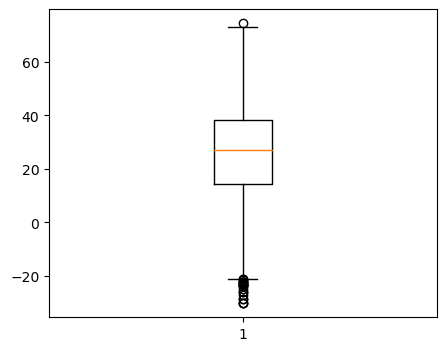

In [7]:
fig = plt.figure(figsize =(5, 4))

# Creating boxplot plot
plt.boxplot(u_winter)
plt.show()

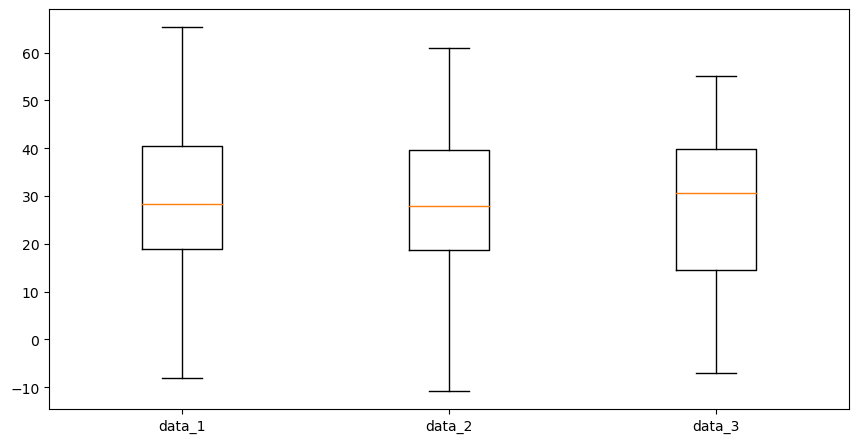

In [19]:
data_1 = u_winter.sel(time=u_winter.time.dt.year.isin([1980,1981,1982]))
data_2 = u_winter.sel(time=u_winter.time.dt.year.isin([1990,1991,1992]))
data_3 = u_winter.sel(time=u_winter.time.dt.year.isin([2010,2011,2012]))
data_plot = [data_1, data_2, data_3]
fig = plt.figure(figsize =(8, 4))

# Creating axes instance
ax = fig.add_axes([0, 0, 1, 1])

# Creating plot
bp = ax.boxplot(data_plot)

# x-axis labels
ax.set_xticklabels(['data_1', 'data_2', 'data_3'])
# show plot
plt.show()

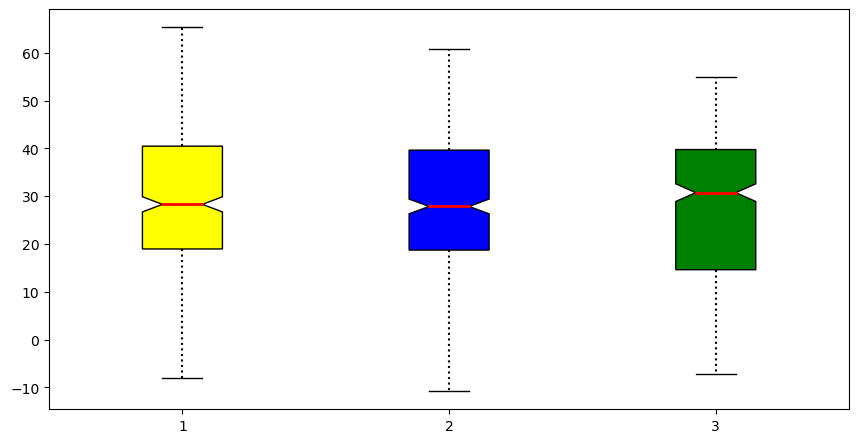

In [22]:
data_1 = u_winter.sel(time=u_winter.time.dt.year.isin([1980,1981,1982])).values
data_2 = u_winter.sel(time=u_winter.time.dt.year.isin([1990,1991,1992])).values
data_3 = u_winter.sel(time=u_winter.time.dt.year.isin([2010,2011,2012])).values
data_plot = [data_1, data_2, data_3]

fig = plt.figure(figsize =(8, 4))
# Creating axes instance
ax = fig.add_axes([0, 0, 1, 1])

# Creating plot
bp = ax.boxplot(data_plot, patch_artist = True,
                notch ='True', vert = 1)

colors = ['yellow', 'blue', 'green']

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# whiskers styles
for whisker in bp['whiskers']:
    whisker.set(color ='k',
                linewidth = 1.5,
                linestyle =":")

# medians styles
for median in bp['medians']:
    median.set(color ='red',
               linewidth = 2)


# show plot
plt.show()

### Histogram

### Use of function: plt.hist(x, bins=None, density=False), let's look at the input of the function one by one.
#### x: input values, this takes either a single array or a sequence of arrays.
#### bins: int or sequence or str,(default: 10). If bins is an integer, it defines the number of equal-width bins in the range. If bins is a sequence, it defines the bin edges, including the left edge of the first bin and the right edge of the last bin.
#### density: bool value, default: False. If True, draw and return a probability density: each bin will display the bin's raw count divided by the total number of counts and the bin width (density = counts / (sum(counts) * np.diff(bins))), so that the area under the histogram integrates to 1 (np.sum(density * np.diff(bins)) == 1).

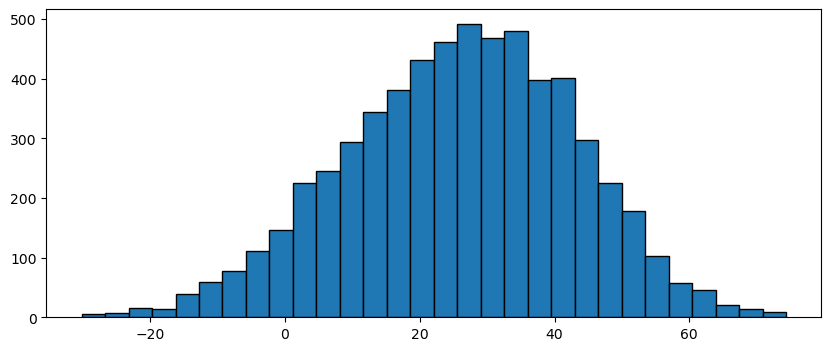

In [10]:
# Plot histogram of u_winter
fig = plt.figure(figsize=(10,4))
plt.hist(u_winter, bins=30, edgecolor="black")
plt.show()

### Output the data for histogram using
#### n, bins, patches = plt.hist()
#### n is the array or list of arrays with values (absolute or relative frequency) of the histogram bins.
#### bins is array showing the edges of the bins, with its length of (n + 1)

(30,) [  6.   7.  15.  14.  39.  59.  77. 111. 146. 225. 246. 294. 345. 381.
 431. 461. 492. 469. 481. 398. 401. 298. 226. 178. 103.  57.  46.  21.
  14.   9.]
(31,) [-30.19643784 -26.71094513 -23.22545052 -19.73995781 -16.2544632
 -12.76896954  -9.28347588  -5.79798269  -2.31248903   1.17300451
   4.65849829   8.14399147  11.62948513  15.11497879  18.6004734
  22.08596611  25.57145882  29.05695343  32.54244614  36.02793884
  39.51343536  42.99892807  46.48442078  49.96991348  53.45541
  56.94090271  60.42639542  63.91188812  67.39738464  70.88287354
  74.36837006]
bin interval: 3.485492706298828


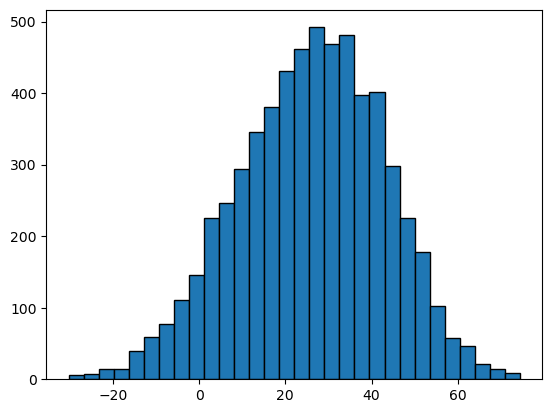

In [15]:
n, bins, patches = plt.hist(u_winter, bins=30, edgecolor="black")
print(n.shape,n)
print(bins.shape,bins)
print('bin interval:',bins[1]-bins[0])

(21,) [  6.  20.  22.  72. 116. 181. 307. 381. 469. 569. 632. 694. 690. 607.
 524. 332. 239.  89.  60.  28.  10.]
(22,) [-30. -25. -20. -15. -10.  -5.   0.   5.  10.  15.  20.  25.  30.  35.
  40.  45.  50.  55.  60.  65.  70.  75.]


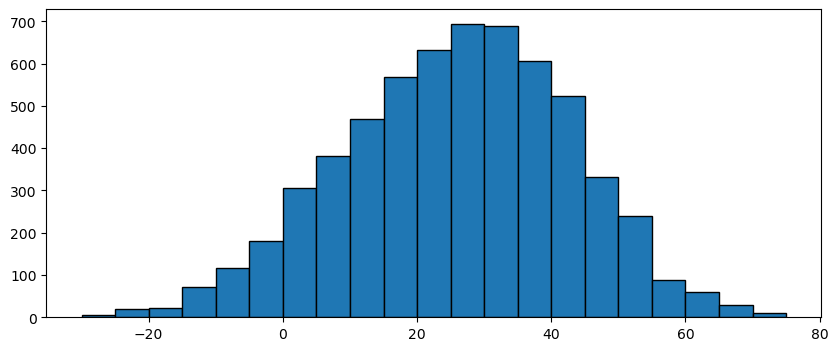

In [9]:
# Define our own bins interval
fig = plt.figure(figsize=(10,4))
n, bins, patches = plt.hist(u_winter,bins=np.arange(-30, 80, 5), edgecolor="black")
print(n.shape,n)
print(bins.shape,bins)

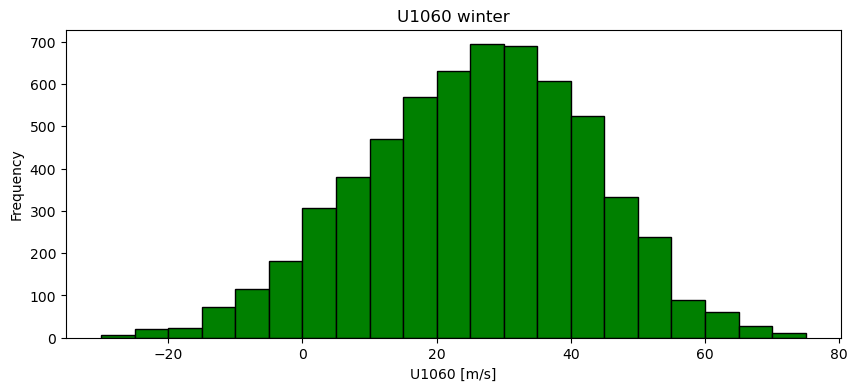

In [21]:
# Define bins color
fig, ax = plt.subplots(figsize=(10,4))
plt.hist(u_winter,bins=np.arange(-30, 80, 5), edgecolor="black", color="green")
plt.title('U1060 winter')
ax.set_xlabel('U1060 [m/s]');
ax.set_ylabel('Frequency');

### The above code is using the absolute frequency, now we use relative frequency.
#### Method 1: using density
#### If density='True', draw and return a probability density: each bin will display the bin's raw count divided by the total number of counts and the bin width (density = counts / (sum(counts) * np.diff(bins))), so that the area under the histogram integrates to 1 (np.sum(density * np.diff(bins)) == 1).

sum of relative frequency of all bins:  1.0


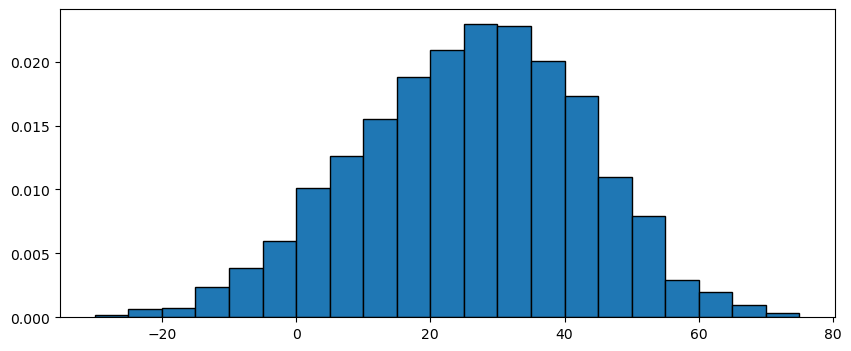

In [25]:
# Setting density as True
fig = plt.figure(figsize=(10,4))
n, bins, patches = plt.hist(u_winter,bins=np.arange(-30, 80, 5), density='True', edgecolor="black")
print('sum of relative frequency of all bins: ',np.sum(n*np.diff(bins)))

### Method 2: using weights
#### weights is an array of weights, of the same shape as the data. Each value in x only contributes its associated weight towards the bin count. 
#### In order to compute the relative frequency as we defined in the lecture slides, which is the number of each bin divided by the sample size, the weights should be an array of 1/N, where N is the sample size. 

(6050,) [0.00016529 0.00016529 0.00016529 ... 0.00016529 0.00016529 0.00016529]
sum of relative frequency of all bins:  0.9996402746764943


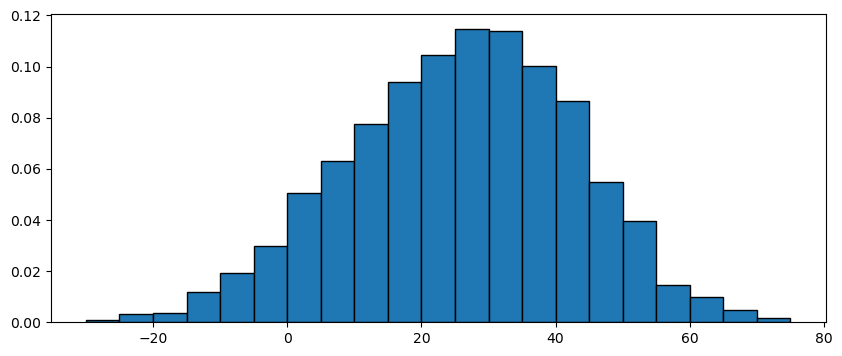

In [32]:
# Plotting relative frequency = (number of each bin)/(sample size)
fig = plt.figure(figsize=(10,4))

# Defining weights
weights = np.ones_like(u_winter.values) / float(len(u_winter.values))
print(weights.shape,weights)

# Plotting histogram with y-axis being relative frequency
n, bins, patches = plt.hist(u_winter,bins=np.arange(-30, 80, 5), weights=weights, edgecolor="black")
print('sum of relative frequency of all bins: ',np.sum(n))

Text(0, 0.5, 'Frequency')

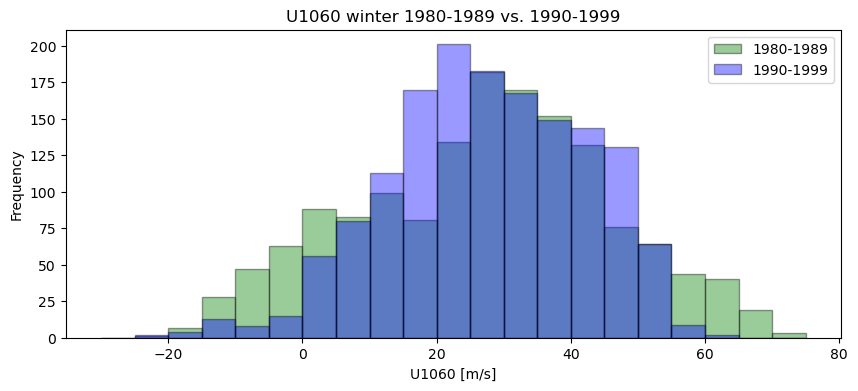

In [38]:
# Compare histograms of two datasets
data_1 = u_winter.sel(time=u_winter.time.dt.year.isin([1980,1981,1982,1983,1984,1985,1986,1987,1988,1989])).values
data_2 = u_winter.sel(time=u_winter.time.dt.year.isin([1990,1991,1992,1993,1994,1995,1996,1997,1998,1999])).values

fig, ax = plt.subplots(figsize=(10,4))
n, bins, patches = plt.hist(data_1, bins=np.arange(-30, 80, 5), edgecolor="black", color="green",alpha=0.4,label='1980-1989')
n, bins, patches = plt.hist(data_2, bins=np.arange(-30, 80, 5), edgecolor="black", color="blue",alpha=0.4,label='1990-1999')
plt.legend()

# add figure title and x-axis label to the histogram
plt.title('U1060 winter 1980-1989 vs. 1990-1999')
ax.set_xlabel('U1060 [m/s]')
ax.set_ylabel('Frequency')

### We can also add the lines to represent the values of the mean/median and/or 25th and 75th percentiles and/or 5th and 95th percentiles.

Text(0, 0.5, 'Frequency')

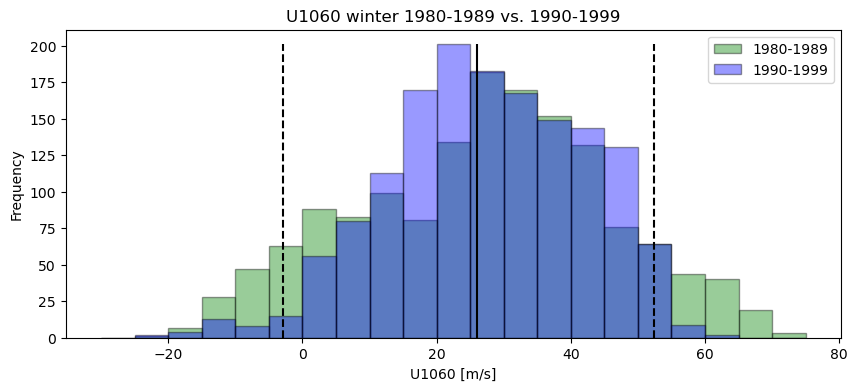

In [42]:
# Compare histograms of two datasets
data_1 = u_winter.sel(time=u_winter.time.dt.year.isin([1980,1981,1982,1983,1984,1985,1986,1987,1988,1989])).values
data_2 = u_winter.sel(time=u_winter.time.dt.year.isin([1990,1991,1992,1993,1994,1995,1996,1997,1998,1999])).values

# Compute mean, 5th, and 95th percentiles of u_winter_1
u_mean = np.mean(u_winter)
u_5per = np.percentile(u_winter, 5)
u_95per = np.percentile(u_winter, 95)

fig, ax = plt.subplots(figsize=(10,4))
n, bins, patches = plt.hist(data_1, bins=np.arange(-30, 80, 5), edgecolor="black", color="green",alpha=0.4,label='1980-1989')
n, bins, patches = plt.hist(data_2, bins=np.arange(-30, 80, 5), edgecolor="black", color="blue",alpha=0.4,label='1990-1999')
plt.legend()

plt.vlines(u_mean, 0, np.amax(n), colors='k')
plt.vlines(u_5per, 0, np.amax(n), colors='k', linestyle='dashed')
plt.vlines(u_95per, 0, np.amax(n), colors='k', linestyle='dashed')

# add figure title and x-axis label to the histogram
plt.title('U1060 winter 1980-1989 vs. 1990-1999')
ax.set_xlabel('U1060 [m/s]')
ax.set_ylabel('Frequency')